# 226 — How much of the answer key is reachable?

The QfO Pfam-region benchmark scores a domain call as a true positive when the
called interval reaches IoU ≥ 0.5 against the true domain. Notebook
[223](./223_mhc_platform_vs_ig_domain.ipynb) showed, on the 51 MHC domains, that this is a
boundary test rather than a homology test. A full-length call against a domain of length `d`
inside a protein of length `L` scores exactly `d / L`, so the call can only pass when the
domain is at least half its protein, or when the target proteome supplies a protein carrying
that family with nothing else on it, from which a tight boundary can be inherited.

This notebook asks the same question of the whole answer key rather than of the MHC. The
truth set is 2,358 human chr6 domain instances across 1,086 Pfam families, searched against
nine proteomes. That is 21,222 (instance, target species) pairs. For how many of them can a
true positive exist at all?

Every number here is the **pfam** truth set only. `all_domain_metrics.parquet` stacks three
truth sets (`pfam`, `pfamn`, `swissprot`) in one file with rows duplicated across them, and
the `swissprot` slice is unusable for cross-species work — Swiss-Prot has 28 reviewed *Ciona*
entries in total, so its coverage ranges 540-fold across the nine species, and its `pfam_id`
column holds a feature type rather than a Pfam family. Every read of that file below filters
`truth_set == "pfam"` first. The truth mirror and the target domain maps are pfam-only
already.

Siblings: [220](./220_mhc_region_map_and_coverage.ipynb) maps the region,
[221](./221_mhc_cross_species_detection_depth.ipynb) walks it out to 2,000 Mya,
[223](./223_mhc_platform_vs_ig_domain.ipynb) found the mechanism on 51 domains.

## 1. The length fraction of the answer key

`length_fraction = (domain_end - domain_start + 1) / protein_length` is the IoU a
full-length call would score. It needs no target information at all. Condition 1 is
`length_fraction ≥ 0.5`.

truth instances: 2358 on 964 human chr6 proteins
Pfam families:   1086
(instance, species) pairs: 21222

domain length / protein length / length fraction:
shape: (6, 4)
┌───────────┬────────────┬─────────────┬─────────────────┐
│ statistic ┆ domain_len ┆ protein_len ┆ length_fraction │
│ ---       ┆ ---        ┆ ---         ┆ ---             │
│ str       ┆ f64        ┆ f64         ┆ f64             │
╞═══════════╪════════════╪═════════════╪═════════════════╡
│ min       ┆ 18.0       ┆ 24.0        ┆ 0.0052          │
│ 25%       ┆ 54.0       ┆ 382.0       ┆ 0.0533          │
│ median    ┆ 90.0       ┆ 612.0       ┆ 0.1326          │
│ 75%       ┆ 151.0      ┆ 1210.0      ┆ 0.3466          │
│ max       ┆ 1435.0     ┆ 8797.0      ┆ 1.6965          │
│ mean      ┆ 124.6      ┆ 1141.3      ┆ 0.2443          │
└───────────┴────────────┴─────────────┴─────────────────┘

length fraction, banded:
shape: (7, 6)
┌───────────┬──────┬────────┬───────────────────┬────────────────────┬─────────────

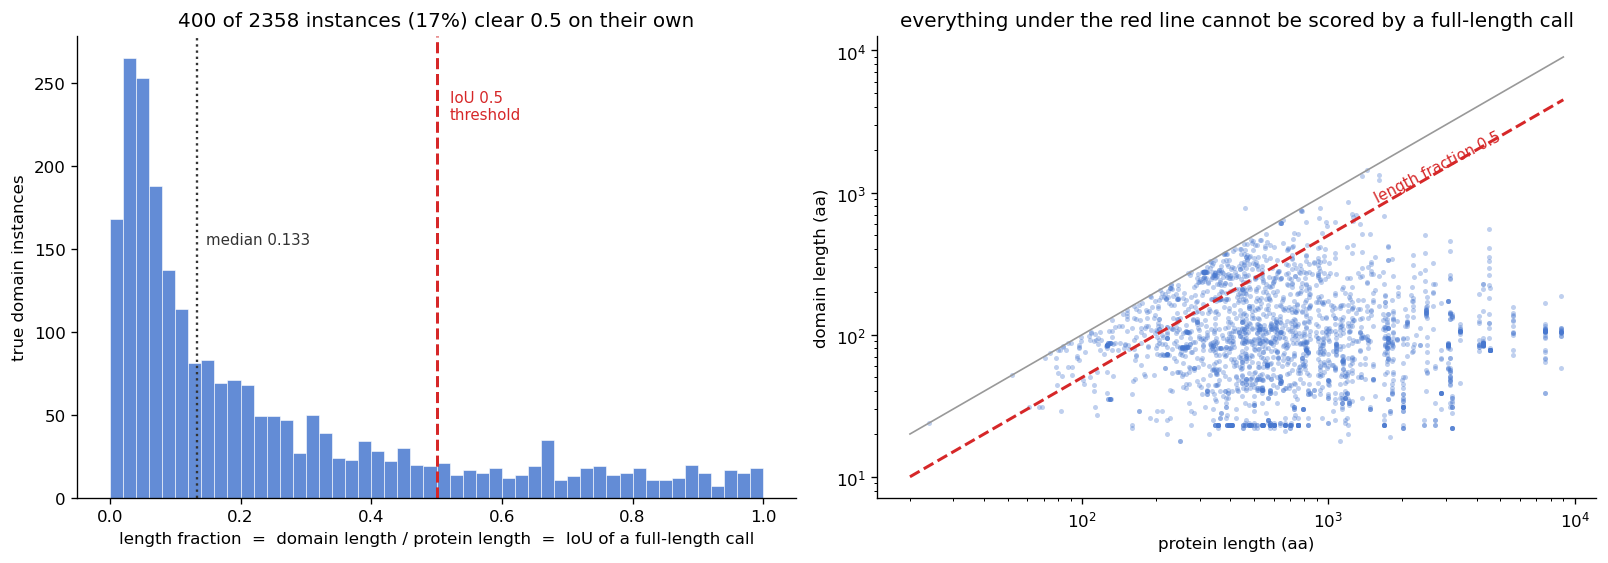

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import mhc_region_utils as mu

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

TRUTH = (
    mu.load_human_truth()
    .with_columns(domain_len=pl.col("domain_end") - pl.col("domain_start") + 1)
    .with_columns(
        length_fraction=(pl.col("domain_end") - pl.col("domain_start") + 1)
        / pl.col("protein_length")
    )
)
N_TRUTH = TRUTH.height
N_PAIRS = N_TRUTH * len(mu.SPECIES_ORDER)

print(
    f"truth instances: {N_TRUTH} on {TRUTH['accession'].n_unique()} human chr6 proteins"
)
print(f"Pfam families:   {TRUTH['pfam_id'].n_unique()}")
print(f"(instance, species) pairs: {N_PAIRS}")
print()
print("domain length / protein length / length fraction:")
desc = pl.DataFrame(
    {
        "statistic": ["min", "25%", "median", "75%", "max", "mean"],
        "domain_len": [
            float(TRUTH["domain_len"].min()),
            float(TRUTH["domain_len"].quantile(0.25)),
            float(TRUTH["domain_len"].median()),
            float(TRUTH["domain_len"].quantile(0.75)),
            float(TRUTH["domain_len"].max()),
            round(float(TRUTH["domain_len"].mean()), 1),
        ],
        "protein_len": [
            float(TRUTH["protein_length"].min()),
            float(TRUTH["protein_length"].quantile(0.25)),
            float(TRUTH["protein_length"].median()),
            float(TRUTH["protein_length"].quantile(0.75)),
            float(TRUTH["protein_length"].max()),
            round(float(TRUTH["protein_length"].mean()), 1),
        ],
        "length_fraction": [
            round(float(TRUTH["length_fraction"].min()), 4),
            round(float(TRUTH["length_fraction"].quantile(0.25)), 4),
            round(float(TRUTH["length_fraction"].median()), 4),
            round(float(TRUTH["length_fraction"].quantile(0.75)), 4),
            round(float(TRUTH["length_fraction"].max()), 4),
            round(float(TRUTH["length_fraction"].mean()), 4),
        ],
    }
)
with pl.Config(tbl_rows=10, tbl_width_chars=120):
    print(desc)

EDGES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.001]
band_rows = []
for lo, hi in zip(EDGES[:-1], EDGES[1:]):
    s = TRUTH.filter(
        (pl.col("length_fraction") >= lo) & (pl.col("length_fraction") < hi)
    )
    band_rows.append(
        {
            "band": f"{lo:.2f}-{hi:.2f}",
            "n": s.height,
            "frac": round(s.height / N_TRUTH, 4),
            "median_domain_len": (
                None if s.height == 0 else int(s["domain_len"].median())
            ),
            "median_protein_len": (
                None if s.height == 0 else int(s["protein_length"].median())
            ),
            "clears_iou_0.5": lo >= 0.5,
        }
    )
bands = pl.DataFrame(band_rows)
n_cond1 = int((TRUTH["length_fraction"] >= 0.5).sum())
print()
print("length fraction, banded:")
with pl.Config(tbl_rows=12, tbl_width_chars=140):
    print(bands)
print()
print(
    f"condition 1 (length_fraction >= 0.5): {n_cond1} of {N_TRUTH} "
    f"= {n_cond1 / N_TRUTH:.1%} of the answer key"
)
print(
    f"the other {N_TRUTH - n_cond1} instances need a tight boundary from somewhere else"
)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]
ax.hist(
    TRUTH["length_fraction"].to_numpy(),
    bins=np.linspace(0, 1, 51),
    color="#4878CF",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)
ax.axvline(0.5, color="#D62728", lw=1.8, ls="--")
ax.axvline(TRUTH["length_fraction"].median(), color="#333333", lw=1.4, ls=":")
ax.text(
    0.52, ax.get_ylim()[1] * 0.82, "IoU 0.5\nthreshold", color="#D62728", fontsize=9
)
ax.text(
    TRUTH["length_fraction"].median() + 0.015,
    ax.get_ylim()[1] * 0.55,
    f"median {TRUTH['length_fraction'].median():.3f}",
    color="#333333",
    fontsize=9,
)
ax.set_xlabel(
    "length fraction  =  domain length / protein length  =  IoU of a full-length call"
)
ax.set_ylabel("true domain instances")
ax.set_title(
    f"{n_cond1} of {N_TRUTH} instances ({n_cond1 / N_TRUTH:.0%}) clear 0.5 on their own"
)

ax = axes[1]
ax.scatter(
    TRUTH["protein_length"].to_numpy(),
    TRUTH["domain_len"].to_numpy(),
    s=9,
    alpha=0.35,
    color="#4878CF",
    linewidth=0,
)
xs = np.array([20, 9000])
ax.plot(xs, xs, color="#999999", lw=1.0, ls="-")
ax.plot(xs, 0.5 * xs, color="#D62728", lw=1.8, ls="--")
ax.text(
    1500,
    1500 * 0.5 * 1.15,
    "length fraction 0.5",
    color="#D62728",
    fontsize=9,
    rotation=27,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("protein length (aa)")
ax.set_ylabel("domain length (aa)")
ax.set_title("everything under the red line cannot be scored by a full-length call")
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "226_length_fraction.png", dpi=200)

## 2. Single-domain targets: where a tight boundary can come from

The pipeline transfers every Pfam family annotated on a matched target protein onto the
aligned query interval. If every target protein carrying family F also carries something
else, the transferred interval tends to span both, and the call overruns the domain.
Condition 2 asks whether the target proteome holds at least one protein whose *only* Pfam
family is F.

The table also carries `max_target_length_fraction`, the largest fraction of a target
protein that one instance of the family occupies. It is not part of the two-condition rule
but it is used in §4, where it turns out to be the better predictor.

Per target proteome, over the 1,086 families in the answer key:
shape: (9, 8)
┌─────────────┬────────────┬──────────────────┬────────────────────┬──────────────────────────┬──────────────────────────┬──────────────┬────────────────┐
│ species     ┆ n_families ┆ families_present ┆ families_with_solo ┆ families_present_no_solo ┆ median_solo_when_present ┆ frac_present ┆ frac_with_solo │
│ ---         ┆ ---        ┆ ---              ┆ ---                ┆ ---                      ┆ ---                      ┆ ---          ┆ ---            │
│ str         ┆ u32        ┆ u32              ┆ u32                ┆ u32                      ┆ f64                      ┆ f64          ┆ f64            │
╞═════════════╪════════════╪══════════════════╪════════════════════╪══════════════════════════╪══════════════════════════╪══════════════╪════════════════╡
│ mouse       ┆ 1086       ┆ 1073             ┆ 536                ┆ 537                      ┆ 0.0                      ┆ 0.988        ┆ 0.494    

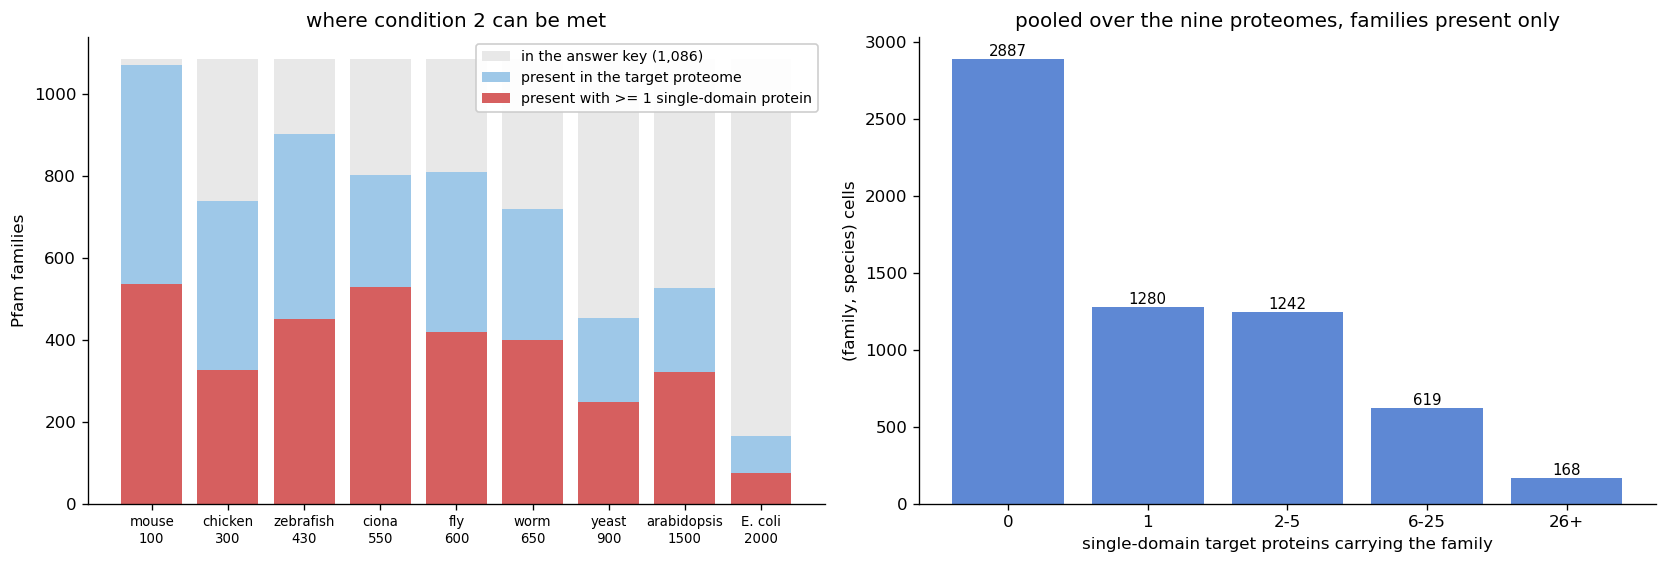

In [2]:
FAMS = sorted(TRUTH["pfam_id"].unique().to_list())

avail_parts = []
for sp in mu.SPECIES_ORDER:
    dm = mu.load_target_domain_map(sp).with_columns(
        tlf=(pl.col("domain_end") - pl.col("domain_start") + 1)
        / pl.col("protein_length")
    )
    n_fam_on_protein = dm.group_by("accession").agg(
        pl.col("pfam_id").n_unique().alias("n_fam")
    )
    dm = dm.join(n_fam_on_protein, on="accession", how="left")
    agg = dm.group_by("pfam_id").agg(
        n_target_proteins=pl.col("accession").n_unique(),
        n_solo_targets=pl.col("accession").filter(pl.col("n_fam") == 1).n_unique(),
        max_target_length_fraction=pl.col("tlf").max(),
    )
    # Zero-fill across every family in the answer key: a family with no row here is a zero,
    # not a missing value.
    part = (
        pl.DataFrame({"pfam_id": FAMS})
        .join(agg, on="pfam_id", how="left")
        .with_columns(
            pl.col("n_target_proteins").fill_null(0),
            pl.col("n_solo_targets").fill_null(0),
            pl.col("max_target_length_fraction").fill_null(0.0),
            species=pl.lit(sp),
        )
    )
    avail_parts.append(part)
AVAIL = pl.concat(avail_parts)

per_species = (
    AVAIL.group_by("species")
    .agg(
        n_families=pl.len(),
        families_present=(pl.col("n_target_proteins") > 0).sum(),
        families_with_solo=(pl.col("n_solo_targets") > 0).sum(),
        families_present_no_solo=(
            (pl.col("n_target_proteins") > 0) & (pl.col("n_solo_targets") == 0)
        ).sum(),
        median_solo_when_present=pl.col("n_solo_targets")
        .filter(pl.col("n_target_proteins") > 0)
        .median(),
    )
    .with_columns(
        frac_present=(pl.col("families_present") / pl.col("n_families")).round(3),
        frac_with_solo=(pl.col("families_with_solo") / pl.col("n_families")).round(3),
    )
    .sort("species")
)
order = pl.DataFrame({"species": mu.SPECIES_ORDER, "_o": range(len(mu.SPECIES_ORDER))})
per_species = per_species.join(order, on="species").sort("_o").drop("_o")
print("Per target proteome, over the 1,086 families in the answer key:")
with pl.Config(tbl_rows=12, tbl_width_chars=190):
    print(per_species)
print()
print("Distribution of n_solo_targets among families that are present at all:")
solo_present = AVAIL.filter(pl.col("n_target_proteins") > 0)
solo_bands = pl.DataFrame(
    {
        "n_solo_targets": ["0", "1", "2-5", "6-25", "26+"],
        "n_family_species_cells": [
            solo_present.filter(pl.col("n_solo_targets") == 0).height,
            solo_present.filter(pl.col("n_solo_targets") == 1).height,
            solo_present.filter(pl.col("n_solo_targets").is_between(2, 5)).height,
            solo_present.filter(pl.col("n_solo_targets").is_between(6, 25)).height,
            solo_present.filter(pl.col("n_solo_targets") >= 26).height,
        ],
    }
)
with pl.Config(tbl_rows=10, tbl_width_chars=120):
    print(solo_bands)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(mu.SPECIES_ORDER))
present = [
    per_species.filter(pl.col("species") == s)["families_present"][0]
    for s in mu.SPECIES_ORDER
]
withsolo = [
    per_species.filter(pl.col("species") == s)["families_with_solo"][0]
    for s in mu.SPECIES_ORDER
]
ax = axes[0]
ax.bar(x, [len(FAMS)] * len(x), color="#e8e8e8", label="in the answer key (1,086)")
ax.bar(x, present, color="#9EC8E8", label="present in the target proteome")
ax.bar(x, withsolo, color="#D65F5F", label="present with >= 1 single-domain protein")
ax.set_xticks(x)
ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
ax.set_ylabel("Pfam families")
ax.set_title("where condition 2 can be met")
ax.legend(fontsize=8.5, loc="upper right", framealpha=0.95)

ax = axes[1]
vals = solo_bands["n_family_species_cells"].to_list()
ax.bar(range(len(vals)), vals, color="#4878CF", alpha=0.88)
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(solo_bands["n_solo_targets"].to_list())
ax.set_xlabel("single-domain target proteins carrying the family")
ax.set_ylabel("(family, species) cells")
ax.set_title("pooled over the nine proteomes, families present only")
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "226_single_domain_targets.png", dpi=200)

## 3. The census

Every (instance, species) pair is put in one of five classes.

- **family absent from target** — no target protein carries the family, so no transfer can
  ever produce it. This is a hard floor, not a heuristic.
- **present but structurally unreachable** — the family is there, but the domain is under
  half its protein and no target carries the family alone.
- **reachable via length fraction** — condition 1 only.
- **reachable via single-domain target** — condition 2 only.
- **reachable via both**.

Census over 21,222 (instance, species) pairs:
shape: (5, 3)
┌──────────────────────────────────────┬──────┬────────┐
│ reach_class                          ┆ len  ┆ frac   │
│ ---                                  ┆ ---  ┆ ---    │
│ str                                  ┆ u32  ┆ f64    │
╞══════════════════════════════════════╪══════╪════════╡
│ family absent from target            ┆ 6770 ┆ 0.319  │
│ present but structurally unreachable ┆ 4588 ┆ 0.2162 │
│ reachable via length fraction        ┆ 225  ┆ 0.0106 │
│ reachable via single-domain target   ┆ 7522 ┆ 0.3544 │
│ reachable via both                   ┆ 2117 ┆ 0.0998 │
└──────────────────────────────────────┴──────┴────────┘

guaranteed miss, family absent:                  6770  31.9%
predicted miss, present but unreachable:         4588  21.6%
total not predicted reachable:                  11358  53.5%
predicted reachable:                             9864  46.5%

Per species (each row sums to 2,358):
shape: (9, 7)
┌─────────────┬

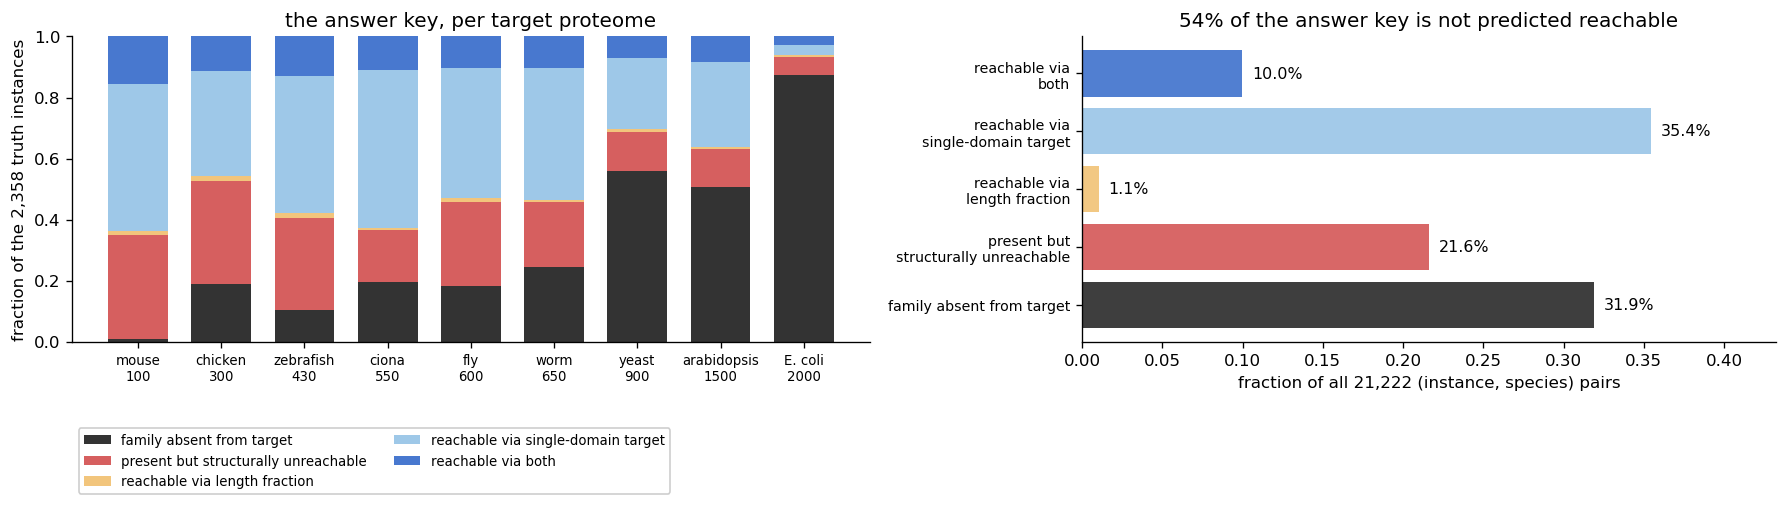

In [3]:
CENSUS = TRUTH.join(AVAIL, on="pfam_id", how="left").with_columns(
    present=pl.col("n_target_proteins") > 0,
    cond1=pl.col("length_fraction") >= 0.5,
    cond2=pl.col("n_solo_targets") > 0,
)
CENSUS = CENSUS.with_columns(
    reach_class=pl.when(~pl.col("present"))
    .then(pl.lit("family absent from target"))
    .when(pl.col("cond1") & pl.col("cond2"))
    .then(pl.lit("reachable via both"))
    .when(pl.col("cond1"))
    .then(pl.lit("reachable via length fraction"))
    .when(pl.col("cond2"))
    .then(pl.lit("reachable via single-domain target"))
    .otherwise(pl.lit("present but structurally unreachable")),
    reachable=pl.col("present") & (pl.col("cond1") | pl.col("cond2")),
)
assert CENSUS.height == N_PAIRS, CENSUS.height

CLASS_ORDER = [
    "family absent from target",
    "present but structurally unreachable",
    "reachable via length fraction",
    "reachable via single-domain target",
    "reachable via both",
]
CLASS_COLORS = {
    "family absent from target": "#333333",
    "present but structurally unreachable": "#D65F5F",
    "reachable via length fraction": "#F2C57C",
    "reachable via single-domain target": "#9EC8E8",
    "reachable via both": "#4878CF",
}

overall = (
    CENSUS.group_by("reach_class")
    .len()
    .with_columns(frac=(pl.col("len") / N_PAIRS).round(4))
)
overall = (
    pl.DataFrame({"reach_class": CLASS_ORDER})
    .join(overall, on="reach_class", how="left")
    .with_columns(pl.col("len").fill_null(0), pl.col("frac").fill_null(0.0))
)
print(f"Census over {N_PAIRS:,} (instance, species) pairs:")
with pl.Config(tbl_rows=10, tbl_width_chars=140, fmt_str_lengths=45):
    print(overall)

n_absent = int(CENSUS.filter(~pl.col("present")).height)
n_unreach = int(CENSUS.filter(pl.col("present") & ~pl.col("reachable")).height)
n_reach = int(CENSUS["reachable"].sum())
print()
print(
    f"guaranteed miss, family absent:                {n_absent:6d}  {n_absent / N_PAIRS:.1%}"
)
print(
    f"predicted miss, present but unreachable:       {n_unreach:6d}  {n_unreach / N_PAIRS:.1%}"
)
print(
    f"total not predicted reachable:                 {n_absent + n_unreach:6d}"
    f"  {(n_absent + n_unreach) / N_PAIRS:.1%}"
)
print(
    f"predicted reachable:                           {n_reach:6d}  {n_reach / N_PAIRS:.1%}"
)

per_sp = (
    CENSUS.group_by("species", "reach_class")
    .len()
    .pivot(on="reach_class", index="species", values="len")
)
for c in CLASS_ORDER:
    if c not in per_sp.columns:
        per_sp = per_sp.with_columns(pl.lit(0).alias(c))
per_sp = (
    per_sp.fill_null(0)
    .select(["species"] + CLASS_ORDER)
    .with_columns(
        frac_reachable=(
            (
                pl.col("reachable via both")
                + pl.col("reachable via length fraction")
                + pl.col("reachable via single-domain target")
            )
            / N_TRUTH
        ).round(3)
    )
    .join(order, on="species")
    .sort("_o")
    .drop("_o")
)
print()
print("Per species (each row sums to 2,358):")
with pl.Config(tbl_rows=12, tbl_width_chars=220, fmt_str_lengths=40):
    print(per_sp)

# Cross-check against the pipeline's own presence-based denominator, pfam slice only.
metrics = pl.read_parquet(mu.ALL_DOMAIN_METRICS).filter(
    (pl.col("truth_set") == "pfam")
    & (pl.col("stratum_axis") == "all")
    & (pl.col("dedup_transfers") == False)
    & (pl.col("split") == "all")
    & (pl.col("species") != "all")
    & (pl.col("tool") != "hmmscan")
)
pipe_present = (
    metrics.group_by("species")
    .agg(pipeline_n_reachable=pl.col("n_reachable_instances").max())
    .join(
        per_sp.select(
            "species", mine=pl.lit(N_TRUTH) - pl.col("family absent from target")
        ),
        on="species",
        how="inner",
    )
    .with_columns(agrees=pl.col("pipeline_n_reachable") == pl.col("mine"))
)
print()
print(
    "Cross-check: the pipeline's own reachability denominator counts family presence only."
)
with pl.Config(tbl_rows=12, tbl_width_chars=140):
    print(pipe_present.sort("species"))

fig, axes = plt.subplots(
    1, 2, figsize=(15, 5.0), gridspec_kw={"width_ratios": [1.15, 1]}
)
ax = axes[0]
bottom = np.zeros(len(mu.SPECIES_ORDER))
for c in CLASS_ORDER:
    vals = (
        np.array(
            [per_sp.filter(pl.col("species") == s)[c][0] for s in mu.SPECIES_ORDER],
            dtype=float,
        )
        / N_TRUTH
    )
    ax.bar(
        np.arange(len(mu.SPECIES_ORDER)),
        vals,
        bottom=bottom,
        color=CLASS_COLORS[c],
        label=c,
        width=0.72,
    )
    bottom += vals
ax.set_xticks(np.arange(len(mu.SPECIES_ORDER)))
ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
ax.set_ylabel("fraction of the 2,358 truth instances")
ax.set_ylim(0, 1)
ax.set_title("the answer key, per target proteome")
ax.legend(
    fontsize=8, loc="lower left", framealpha=0.95, bbox_to_anchor=(0.0, -0.52), ncol=2
)

ax = axes[1]
vals = [overall.filter(pl.col("reach_class") == c)["frac"][0] for c in CLASS_ORDER]
ax.barh(
    range(len(CLASS_ORDER)),
    vals,
    color=[CLASS_COLORS[c] for c in CLASS_ORDER],
    alpha=0.95,
)
for i, v in enumerate(vals):
    ax.text(v + 0.006, i, f"{v:.1%}", va="center", fontsize=9.5)
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_yticklabels(
    [c.replace(" but ", " but\n").replace(" via ", " via\n") for c in CLASS_ORDER],
    fontsize=8.5,
)
ax.set_xlim(0, max(vals) * 1.22)
ax.set_xlabel(f"fraction of all {N_PAIRS:,} (instance, species) pairs")
ax.set_title(
    f"{(n_absent + n_unreach) / N_PAIRS:.0%} of the answer key is not predicted reachable"
)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "226_census.png", dpi=200)

## 4. Does it predict what actually happened?

The census is arithmetic about the truth set and the target annotations. Whether it predicts
outcomes is a separate question, and the run answers it locally: `chr6_calls_focus` holds
every raw call for all 964 chr6 query proteins across nine species and sixteen arms, which
is the whole answer key rather than a subset.

The call table identifies a call by (query protein, Pfam family) and does not say which
*instance* of a repeated family it matched, so this section works at
(protein, family, species) level: 1,747 protein-family pairs, 15,723 pairs with a species.
An instance-level and a pair-level denominator differ by the 611 instances that are repeats
of a family already on the same protein.

§4.1 does the MHC subset, §4.2 the whole answer key, §4.3 the covariates.

MHC subset: 24 curated genes, the ten headline arms.
  459 (gene, family) pairs x 9 species, 10 arms
shape: (2, 4)
┌───────────┬─────────┬────────────────┬──────────────┐
│ reachable ┆ n_cells ┆ delimited_rate ┆ covered_rate │
│ ---       ┆ ---     ┆ ---            ┆ ---          │
│ bool      ┆ u32     ┆ f64            ┆ f64          │
╞═══════════╪═════════╪════════════════╪══════════════╡
│ true      ┆ 1180    ┆ 0.7534         ┆ 0.7873       │
│ false     ┆ 3410    ┆ 0.0654         ┆ 0.1909       │
└───────────┴─────────┴────────────────┴──────────────┘
shape: (2, 3)
┌───────────┬─────┬────────────────────────────┐
│ reachable ┆ n   ┆ ever_delimited_by_some_arm │
│ ---       ┆ --- ┆ ---                        │
│ bool      ┆ u32 ┆ f64                        │
╞═══════════╪═════╪════════════════════════════╡
│ true      ┆ 118 ┆ 0.9831                     │
│ false     ┆ 341 ┆ 0.2111                     │
└───────────┴─────┴────────────────────────────┘

MHC subset, per Pfam family (f

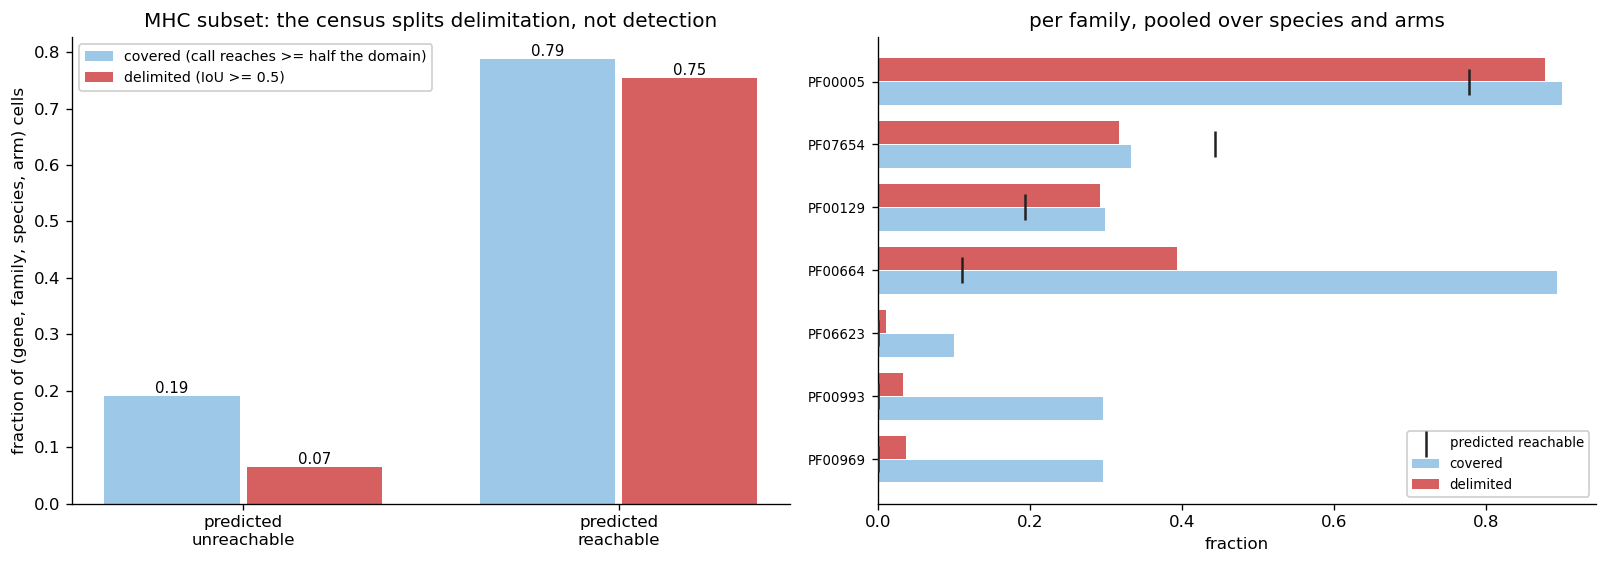

In [4]:
# --- 4.1 the 24 curated MHC genes, from the collapsed per-domain table ---
core = mu.load_chr6_gene_map().filter(pl.col("mhc_class").is_not_null())
mhc_truth = TRUTH.rename({"accession": "query_acc"}).join(
    core.select(query_acc="accession", hgnc_symbol="hgnc_symbol"),
    on="query_acc",
    how="inner",
)
mhc_pairs = (
    mhc_truth.group_by("query_acc", "hgnc_symbol", "pfam_id")
    .agg(max_lf=pl.col("length_fraction").max())
    .join(AVAIL, on="pfam_id", how="left")
    .with_columns(
        present=pl.col("n_target_proteins") > 0,
        cond1=pl.col("max_lf") >= 0.5,
        cond2=pl.col("n_solo_targets") > 0,
    )
)
mhc_pairs = mhc_pairs.with_columns(
    reachable=pl.col("present") & (pl.col("cond1") | pl.col("cond2"))
)

dl = (
    mu.load_domain_level()
    .filter(pl.col("truth_set") == "pfam")
    .with_columns(arm=pl.col("tool") + "." + pl.col("variant"))
)
MHC_ARMS = [
    "hmmer3_phmmer.default",
    "hmmer3_jackhmmer.n3",
    "hhblits.single_seq",
    "mmseqs2_seqseq.s7",
    "mmseqs2_iterative.s7",
    "foldseek.3di_aa",
    "reseek.verysensitive",
    "prostt5.3di_from_seq",
    "folddisco.motif",
    "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue",
]
dl = dl.filter(pl.col("arm").is_in(MHC_ARMS))
mhc_arms = dl.select("tool", "variant").unique()
mhc_grid = (
    mhc_pairs.join(mhc_arms, how="cross")
    .join(
        dl.select(
            "query_acc",
            "pfam_id",
            "species",
            "tool",
            "variant",
            "found",
            "best_iou",
            "best_cover",
        ),
        on=["query_acc", "pfam_id", "species", "tool", "variant"],
        how="left",
    )
    .with_columns(
        pl.col("found").fill_null(False),
        pl.col("best_iou").fill_null(0.0),
        pl.col("best_cover").fill_null(0.0),
    )
)
mhc_tab = (
    mhc_grid.group_by("reachable")
    .agg(
        n_cells=pl.len(),
        delimited_rate=pl.col("found").mean().round(4),
        covered_rate=(pl.col("best_cover") >= 0.5).mean().round(4),
    )
    .sort("reachable", descending=True)
)
mhc_ever = (
    mhc_grid.group_by("query_acc", "hgnc_symbol", "pfam_id", "species", "reachable")
    .agg(ever=pl.col("found").max())
    .group_by("reachable")
    .agg(n=pl.len(), ever_delimited_by_some_arm=pl.col("ever").mean().round(4))
    .sort("reachable", descending=True)
)
print("MHC subset: 24 curated genes, the ten headline arms.")
print(
    f"  {mhc_pairs.height} (gene, family) pairs x 9 species, "
    f"{mhc_grid.select('tool', 'variant').n_unique()} arms"
)
with pl.Config(tbl_rows=10, tbl_width_chars=140):
    print(mhc_tab)
    print(mhc_ever)

by_fam = (
    mhc_grid.group_by("pfam_id")
    .agg(
        reachable_frac=pl.col("reachable").mean().round(3),
        delimited=pl.col("found").mean().round(3),
        covered=(pl.col("best_cover") >= 0.5).mean().round(3),
        n=pl.len(),
    )
    .filter(pl.col("n") >= 30)
    .sort("reachable_frac", descending=True)
)
print()
print("MHC subset, per Pfam family (families with >= 30 arm-species cells):")
with pl.Config(tbl_rows=40, tbl_width_chars=150):
    print(by_fam)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]
lab = ["predicted\nunreachable", "predicted\nreachable"]
d = [
    mhc_tab.filter(~pl.col("reachable"))["delimited_rate"][0],
    mhc_tab.filter(pl.col("reachable"))["delimited_rate"][0],
]
c = [
    mhc_tab.filter(~pl.col("reachable"))["covered_rate"][0],
    mhc_tab.filter(pl.col("reachable"))["covered_rate"][0],
]
xx = np.arange(2)
ax.bar(
    xx - 0.19,
    c,
    0.36,
    color="#9EC8E8",
    label="covered (call reaches >= half the domain)",
)
ax.bar(xx + 0.19, d, 0.36, color="#D65F5F", label="delimited (IoU >= 0.5)")
for i, (cv, dv) in enumerate(zip(c, d)):
    ax.text(i - 0.19, cv, f"{cv:.2f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + 0.19, dv, f"{dv:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(xx)
ax.set_xticklabels(lab)
ax.set_ylabel("fraction of (gene, family, species, arm) cells")
ax.set_title("MHC subset: the census splits delimitation, not detection")
ax.legend(fontsize=8.5, loc="upper left", framealpha=0.95)

ax = axes[1]
b = by_fam.sort("reachable_frac")
yy = np.arange(b.height)
ax.barh(yy - 0.19, b["covered"], 0.36, color="#9EC8E8", label="covered")
ax.barh(yy + 0.19, b["delimited"], 0.36, color="#D65F5F", label="delimited")
ax.scatter(
    b["reachable_frac"],
    yy,
    marker="|",
    s=260,
    color="#222222",
    zorder=5,
    label="predicted reachable",
)
ax.set_yticks(yy)
ax.set_yticklabels(b["pfam_id"], fontsize=8)
ax.set_xlabel("fraction")
ax.set_title("per family, pooled over species and arms")
ax.legend(fontsize=8, loc="lower right", framealpha=0.95)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "226_mhc_subset_check.png", dpi=200)

### 4.2 The whole answer key, sixteen arms

The same test over all 964 query proteins. `folddisco` is held out of the pooled numbers
because it is scored under different interval semantics; §5.2 handles it on its own.

protein-family pairs: 964 proteins, 1747 pairs
pair x species cells: 15723, arms: 16, grid rows: 251568

Per arm, over all 15,723 pair-species cells. folddisco excluded (see 5.2).
shape: (15, 5)
┌──────────────────────────────────────┬───────────┬────────────────────────┬──────────────────────────┬─────────┐
│ arm                                  ┆ delimited ┆ delimited_if_reachable ┆ delimited_if_unreachable ┆ covered │
│ ---                                  ┆ ---       ┆ ---                    ┆ ---                      ┆ ---     │
│ str                                  ┆ f64       ┆ f64                    ┆ f64                      ┆ f64     │
╞══════════════════════════════════════╪═══════════╪════════════════════════╪══════════════════════════╪═════════╡
│ hhblits.single_seq                   ┆ 0.4474    ┆ 0.8825                 ┆ 0.3135                   ┆ 0.619   │
│ hmmer3_jackhmmer.n3                  ┆ 0.4236    ┆ 0.816                  ┆ 0.3316                   ┆ 0.5957  │


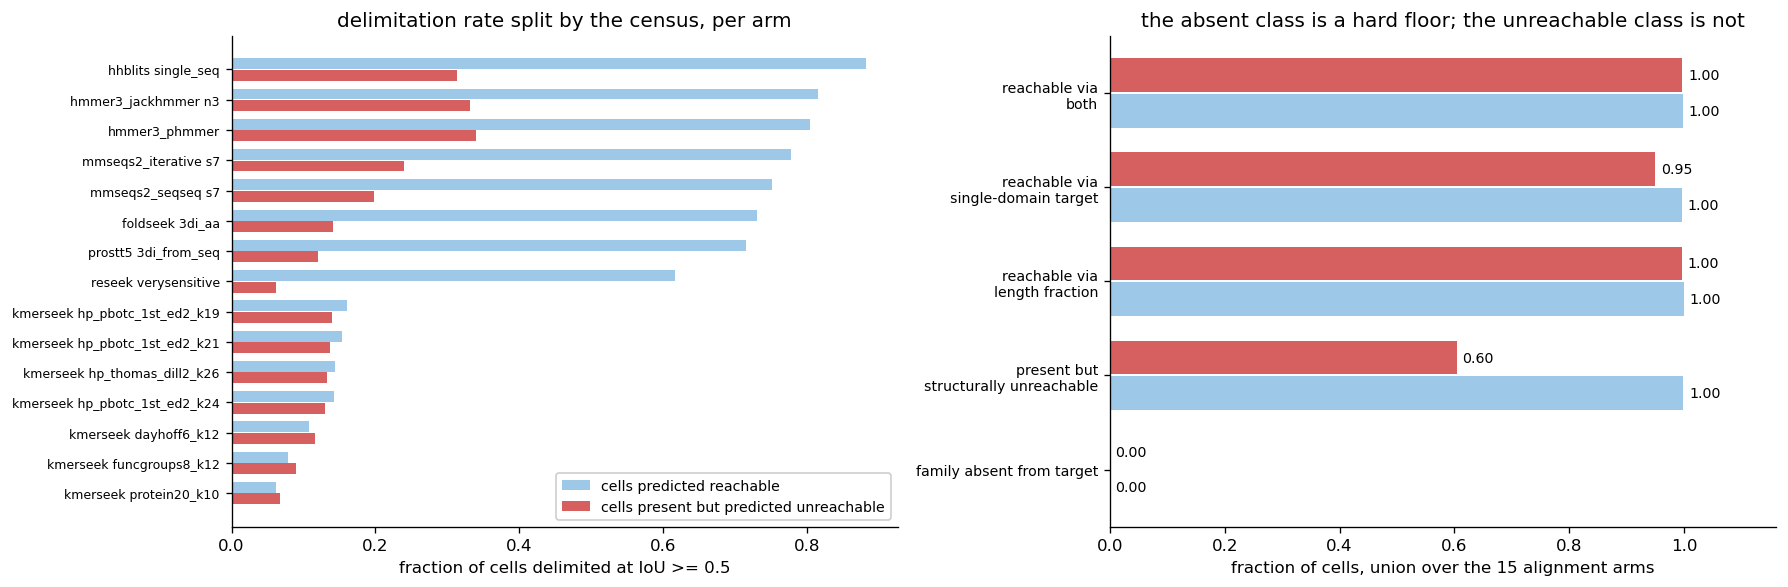

In [5]:
PAIRS = (
    TRUTH.rename({"accession": "query_acc"})
    .group_by("query_acc", "pfam_id")
    .agg(
        max_lf=pl.col("length_fraction").max(),
        mean_lf=pl.col("length_fraction").mean(),
        n_instances=pl.len(),
    )
    .join(AVAIL, on="pfam_id", how="left")
    .with_columns(
        present=pl.col("n_target_proteins") > 0,
        cond1=pl.col("max_lf") >= 0.5,
        cond2=pl.col("n_solo_targets") > 0,
    )
)
PAIRS = PAIRS.with_columns(
    reachable=pl.col("present") & (pl.col("cond1") | pl.col("cond2")),
    reach_class=pl.when(pl.col("n_target_proteins") == 0)
    .then(pl.lit("family absent from target"))
    .when((pl.col("max_lf") >= 0.5) & (pl.col("n_solo_targets") > 0))
    .then(pl.lit("reachable via both"))
    .when(pl.col("max_lf") >= 0.5)
    .then(pl.lit("reachable via length fraction"))
    .when(pl.col("n_solo_targets") > 0)
    .then(pl.lit("reachable via single-domain target"))
    .otherwise(pl.lit("present but structurally unreachable")),
)

BEST = (
    mu.focus_calls()
    .filter(pl.col("truth_set") == "pfam")
    .group_by("species", "tool", "variant", "query_acc", "pfam_id")
    .agg(
        best_iou=pl.col("iou").max(),
        best_cover=pl.col("cover").max(),
        any_tp=pl.col("is_tp").max(),
        n_calls=pl.len(),
    )
    .collect(engine="streaming")
)
ARMS = BEST.select("tool", "variant").unique()
GRID = (
    PAIRS.join(ARMS, how="cross")
    .join(BEST, on=["species", "tool", "variant", "query_acc", "pfam_id"], how="left")
    .with_columns(
        pl.col("best_iou").fill_null(0.0),
        pl.col("best_cover").fill_null(0.0),
        pl.col("any_tp").fill_null(False),
        pl.col("n_calls").fill_null(0),
        arm=pl.col("tool") + "." + pl.col("variant"),
    )
)
N_CELLS = PAIRS.height
print(
    f"protein-family pairs: {PAIRS['query_acc'].n_unique()} proteins, "
    f"{PAIRS.select('query_acc', 'pfam_id').n_unique()} pairs"
)
print(f"pair x species cells: {N_CELLS}, arms: {ARMS.height}, grid rows: {GRID.height}")

ALN = GRID.filter(pl.col("tool") != "folddisco")
per_arm = (
    ALN.group_by("arm")
    .agg(
        delimited=(pl.col("best_iou") >= 0.5).mean().round(4),
        delimited_if_reachable=(pl.col("best_iou") >= 0.5)
        .filter(pl.col("reachable"))
        .mean()
        .round(4),
        delimited_if_unreachable=(pl.col("best_iou") >= 0.5)
        .filter(pl.col("present") & ~pl.col("reachable"))
        .mean()
        .round(4),
        covered=(pl.col("best_cover") >= 0.5).mean().round(4),
    )
    .sort("delimited", descending=True)
)
print()
print("Per arm, over all 15,723 pair-species cells. folddisco excluded (see 5.2).")
with pl.Config(tbl_rows=20, tbl_width_chars=180, fmt_str_lengths=45):
    print(per_arm)

ever = ALN.group_by(
    "query_acc", "pfam_id", "species", "reach_class", "reachable", "present"
).agg(
    ever_delimited=(pl.col("best_iou") >= 0.5).max(),
    ever_covered=(pl.col("best_cover") >= 0.5).max(),
)
by_class = ever.group_by("reach_class").agg(
    n=pl.len(),
    ever_delimited=pl.col("ever_delimited").mean().round(4),
    ever_covered=pl.col("ever_covered").mean().round(4),
)
by_class = pl.DataFrame({"reach_class": CLASS_ORDER}).join(
    by_class, on="reach_class", how="left"
)
print()
print("Union over the 15 alignment arms: was the cell EVER delimited by anything?")
with pl.Config(tbl_rows=10, tbl_width_chars=150, fmt_str_lengths=45):
    print(by_class)
pred_reach = float(
    PAIRS.join(pl.DataFrame({"x": [0]}), how="cross")["reachable"].mean()
)
best_obs = float(per_arm["delimited"].max())
print()
print(f"predicted reachable fraction (pair level): {pred_reach:.4f}")
print(f"best single arm actually delimited:        {best_obs:.4f}")
print(
    "Condition 2 is a good sufficient rule and a poor necessary one: the absent class is"
)
print("delimited 0% of the time, but the 'present but unreachable' class is not at 0%.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.0))
ax = axes[0]
p = per_arm.sort("delimited")
yy = np.arange(p.height)
ax.barh(
    yy + 0.19,
    p["delimited_if_reachable"],
    0.36,
    color="#9EC8E8",
    label="cells predicted reachable",
)
ax.barh(
    yy - 0.19,
    p["delimited_if_unreachable"],
    0.36,
    color="#D65F5F",
    label="cells present but predicted unreachable",
)
ax.set_yticks(yy)
ax.set_yticklabels(
    [
        a.replace("_lcTrue", "").replace(".default", "").replace(".", " ")
        for a in p["arm"]
    ],
    fontsize=7.5,
)
ax.set_xlabel("fraction of cells delimited at IoU >= 0.5")
ax.set_title("delimitation rate split by the census, per arm")
ax.legend(fontsize=8.5, loc="lower right", framealpha=0.95)

ax = axes[1]
cc = [c for c in CLASS_ORDER]
dv = [by_class.filter(pl.col("reach_class") == c)["ever_delimited"][0] for c in cc]
cv = [by_class.filter(pl.col("reach_class") == c)["ever_covered"][0] for c in cc]
yy = np.arange(len(cc))
ax.barh(yy - 0.19, cv, 0.36, color="#9EC8E8", label="ever covered")
ax.barh(yy + 0.19, dv, 0.36, color="#D65F5F", label="ever delimited")
for i, (a_, b_) in enumerate(zip(cv, dv)):
    ax.text(a_ + 0.01, i - 0.19, f"{a_:.2f}", va="center", fontsize=8.5)
    ax.text(b_ + 0.01, i + 0.19, f"{b_:.2f}", va="center", fontsize=8.5)
ax.set_yticks(yy)
ax.set_yticklabels(
    [c.replace(" but ", " but\n").replace(" via ", " via\n") for c in cc], fontsize=8.5
)
ax.set_xlim(0, 1.16)
ax.set_xlabel("fraction of cells, union over the 15 alignment arms")
ax.set_title("the absent class is a hard floor; the unreachable class is not")
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "226_predicts_recall.png", dpi=200)

### 4.3 How much do the two covariates explain?

Per (family, species) recall regressed on length fraction and single-domain-target count, on
the families present in that target. `max_target_length_fraction` is added as a third
covariate: it is the same mechanism as condition 2 stated continuously, and it is a stronger
predictor than the binary partner-free test.

Variance in per-(family, species) recall explained, families present in the target:
shape: (9, 8)
┌──────────────────────────────────────┬─────────┬────────────────────┬───────────────┬──────────────────┬───────────────────┬───────────────────┬─────────────┐
│ arm                                  ┆ n_cells ┆ r2_length_fraction ┆ r2_log_n_solo ┆ r2_max_target_lf ┆ r2_two_conditions ┆ r2_plus_target_lf ┆ r2_all_four │
│ ---                                  ┆ ---     ┆ ---                ┆ ---           ┆ ---              ┆ ---               ┆ ---               ┆ ---         │
│ str                                  ┆ i64     ┆ f64                ┆ f64           ┆ f64              ┆ f64               ┆ f64               ┆ f64         │
╞══════════════════════════════════════╪═════════╪════════════════════╪═══════════════╪══════════════════╪═══════════════════╪═══════════════════╪═════════════╡
│ hmmer3_phmmer.default                ┆ 6196    ┆ 0.132              ┆ 0.186         ┆ 0.225    

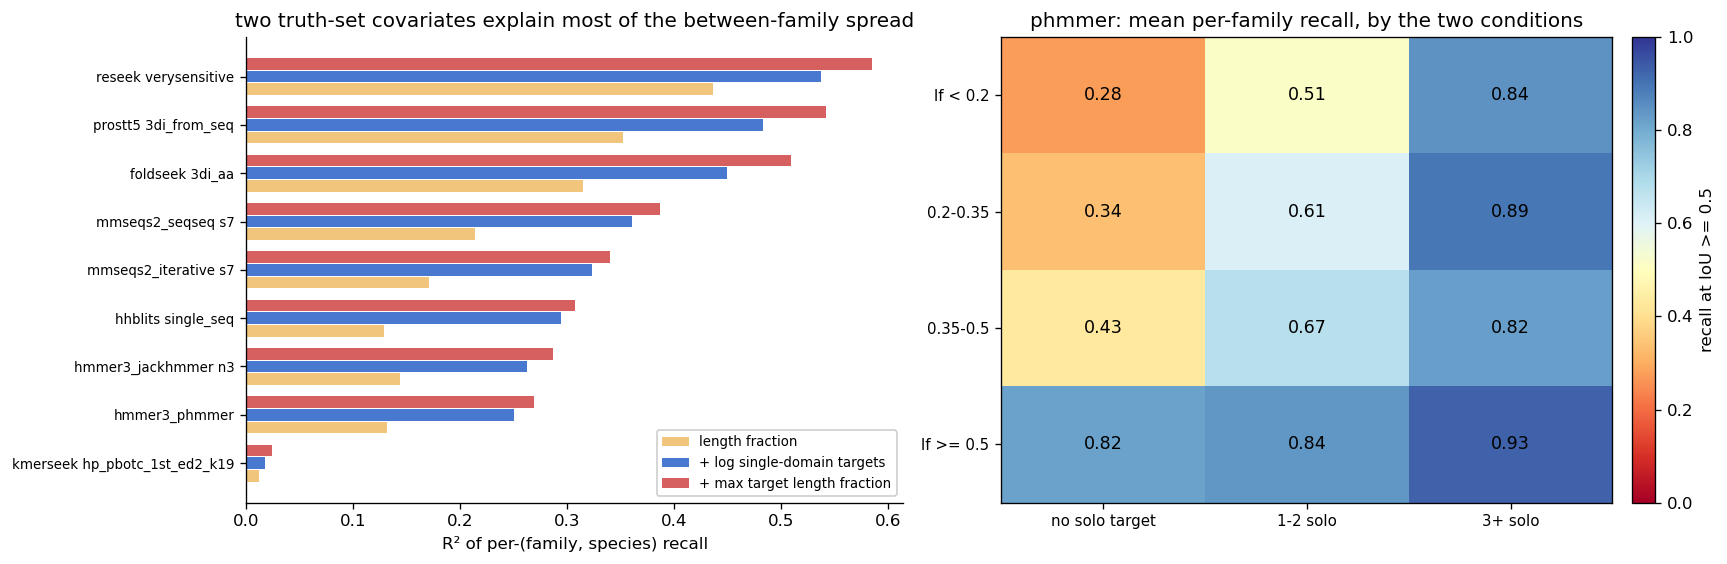

In [6]:
fam_rec_rows = []
FIT_ARMS = [
    "hmmer3_phmmer.default",
    "hhblits.single_seq",
    "mmseqs2_seqseq.s7",
    "foldseek.3di_aa",
    "reseek.verysensitive",
    "prostt5.3di_from_seq",
    "hmmer3_jackhmmer.n3",
    "mmseqs2_iterative.s7",
    "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue",
]
fam_tab = (
    ALN.filter(pl.col("present"))
    .group_by("arm", "pfam_id", "species")
    .agg(
        recall=(pl.col("best_iou") >= 0.5).mean(),
        mean_lf=pl.col("mean_lf").mean(),
        n_solo=pl.col("n_solo_targets").max(),
        n_target=pl.col("n_target_proteins").max(),
        max_tlf=pl.col("max_target_length_fraction").max(),
        n=pl.len(),
    )
)


def r2(y, X):
    X = np.column_stack([np.ones(len(y))] + X)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    return 1.0 - float(resid @ resid) / float(((y - y.mean()) ** 2).sum())


for arm in FIT_ARMS:
    s = fam_tab.filter(pl.col("arm") == arm)
    y = s["recall"].to_numpy()
    lf = s["mean_lf"].to_numpy()
    solo = np.log1p(s["n_solo"].to_numpy().astype(float))
    ntg = np.log1p(s["n_target"].to_numpy().astype(float))
    tlf = s["max_tlf"].to_numpy()
    fam_rec_rows.append(
        {
            "arm": arm,
            "n_cells": s.height,
            "r2_length_fraction": round(r2(y, [lf]), 3),
            "r2_log_n_solo": round(r2(y, [solo]), 3),
            "r2_max_target_lf": round(r2(y, [tlf]), 3),
            "r2_two_conditions": round(r2(y, [lf, solo]), 3),
            "r2_plus_target_lf": round(r2(y, [lf, solo, tlf]), 3),
            "r2_all_four": round(r2(y, [lf, solo, tlf, ntg]), 3),
        }
    )
fit = pl.DataFrame(fam_rec_rows)
print(
    "Variance in per-(family, species) recall explained, families present in the target:"
)
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=45):
    print(fit)
print()
print(
    "Recall by length-fraction band and single-domain-target availability, phmmer pooled:"
)
ph = fam_tab.filter(pl.col("arm") == "hmmer3_phmmer.default")
grid_tab = (
    ph.with_columns(
        lf_band=pl.when(pl.col("mean_lf") < 0.2)
        .then(pl.lit("lf < 0.2"))
        .when(pl.col("mean_lf") < 0.35)
        .then(pl.lit("0.2-0.35"))
        .when(pl.col("mean_lf") < 0.5)
        .then(pl.lit("0.35-0.5"))
        .otherwise(pl.lit("lf >= 0.5")),
        solo_band=pl.when(pl.col("n_solo") == 0)
        .then(pl.lit("no solo target"))
        .when(pl.col("n_solo") <= 2)
        .then(pl.lit("1-2 solo"))
        .otherwise(pl.lit("3+ solo")),
    )
    .group_by("lf_band", "solo_band")
    .agg(recall=pl.col("recall").mean().round(3), n=pl.len())
)
LFB = ["lf < 0.2", "0.2-0.35", "0.35-0.5", "lf >= 0.5"]
SB = ["no solo target", "1-2 solo", "3+ solo"]
with pl.Config(tbl_rows=20, tbl_width_chars=140):
    print(
        grid_tab.pivot(on="solo_band", index="lf_band", values="recall").select(
            ["lf_band"]
            + [c for c in SB if c in grid_tab["solo_band"].unique().to_list()]
        )
    )

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))
ax = axes[0]
f = fit.sort("r2_two_conditions")
yy = np.arange(f.height)
ax.barh(
    yy - 0.26, f["r2_length_fraction"], 0.24, color="#F2C57C", label="length fraction"
)
ax.barh(
    yy,
    f["r2_two_conditions"],
    0.24,
    color="#4878CF",
    label="+ log single-domain targets",
)
ax.barh(
    yy + 0.26,
    f["r2_plus_target_lf"],
    0.24,
    color="#D65F5F",
    label="+ max target length fraction",
)
ax.set_yticks(yy)
ax.set_yticklabels(
    [
        a.replace("_lcTrue", "").replace(".default", "").replace(".", " ")
        for a in f["arm"]
    ],
    fontsize=8,
)
ax.set_xlabel("R² of per-(family, species) recall")
ax.set_title("two truth-set covariates explain most of the between-family spread")
ax.legend(fontsize=8, loc="lower right", framealpha=0.95)

ax = axes[1]
mat = np.full((len(LFB), len(SB)), np.nan)
for i, lb in enumerate(LFB):
    for j, sb in enumerate(SB):
        r = grid_tab.filter((pl.col("lf_band") == lb) & (pl.col("solo_band") == sb))
        if r.height:
            mat[i, j] = r["recall"][0]
im = ax.imshow(mat, cmap="RdYlBu", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(SB)))
ax.set_xticklabels(SB, fontsize=9)
ax.set_yticks(range(len(LFB)))
ax.set_yticklabels(LFB, fontsize=9)
for i in range(len(LFB)):
    for j in range(len(SB)):
        if not np.isnan(mat[i, j]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=10.5)
ax.set_title("phmmer: mean per-family recall, by the two conditions")
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label="recall at IoU >= 0.5")
for s_ in ("right", "top"):
    axes[0].spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "226_covariates.png", dpi=200)

## 5. Three things this explains

### 5.1 Why every Fmax is low

Fmax in this run divides by `n_truth_instances`, which is the full 2,358 for every species.
The census says a large block of that denominator cannot be scored. Recomputing recall
against the reachable block instead shows how much of the low absolute number is the
denominator rather than the search.

Pipeline Fmax, pfam truth, best variant per (tool, species):
shape: (10, 4)
┌───────────────────┬───────────┬──────────┬──────────┐
│ tool              ┆ mean_fmax ┆ min_fmax ┆ max_fmax │
│ ---               ┆ ---       ┆ ---      ┆ ---      │
│ str               ┆ f64       ┆ f64      ┆ f64      │
╞═══════════════════╪═══════════╪══════════╪══════════╡
│ hmmer3_phmmer     ┆ 0.292     ┆ 0.122    ┆ 0.342    │
│ mmseqs2_seqseq    ┆ 0.287     ┆ 0.114    ┆ 0.339    │
│ mmseqs2_iterative ┆ 0.287     ┆ 0.107    ┆ 0.34     │
│ hhblits           ┆ 0.287     ┆ 0.125    ┆ 0.334    │
│ hmmer3_jackhmmer  ┆ 0.269     ┆ 0.123    ┆ 0.309    │
│ foldseek          ┆ 0.227     ┆ 0.123    ┆ 0.265    │
│ prostt5           ┆ 0.201     ┆ 0.116    ┆ 0.249    │
│ reseek            ┆ 0.162     ┆ 0.034    ┆ 0.283    │
│ folddisco         ┆ 0.134     ┆ 0.021    ┆ 0.454    │
│ kmerseek          ┆ 0.117     ┆ 0.0      ┆ 0.437    │
└───────────────────┴───────────┴──────────┴──────────┘

Own recall, averaged over t

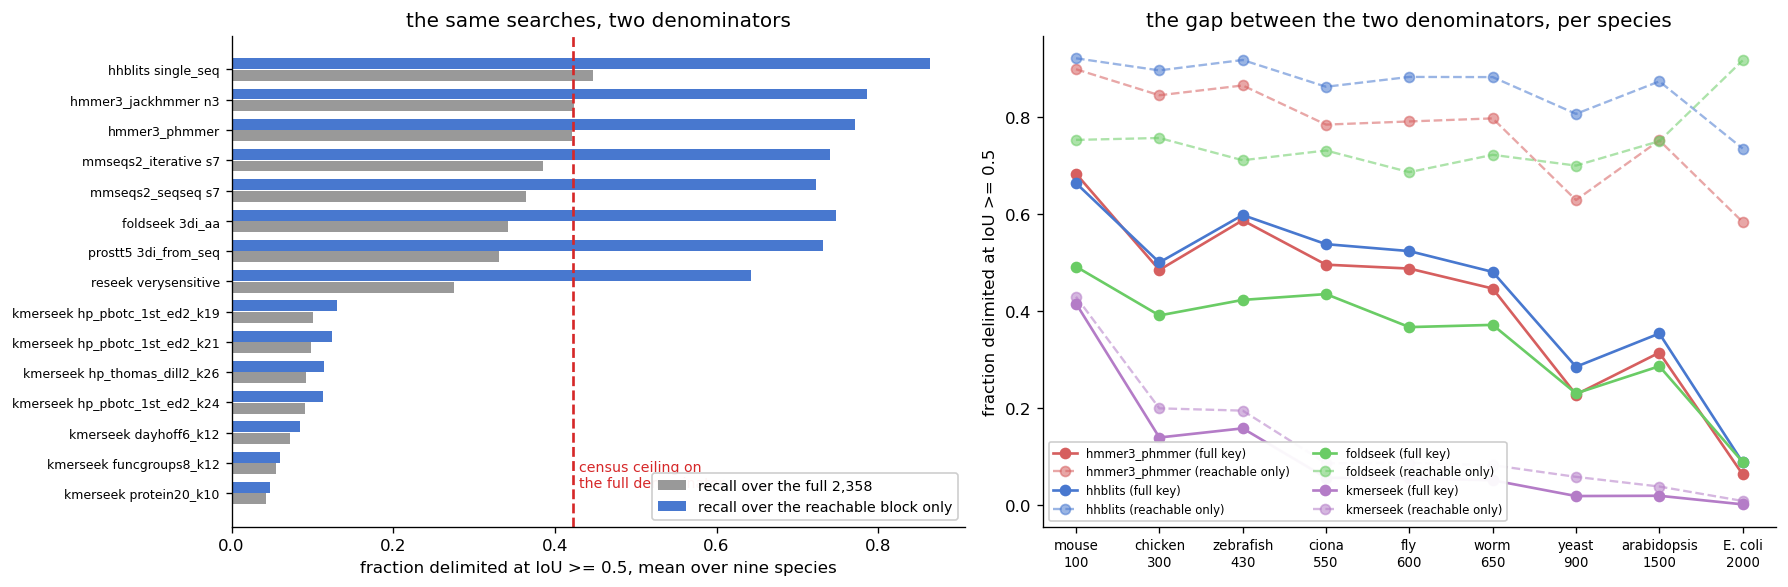

In [7]:
sp_arm = ALN.group_by("arm", "species").agg(
    recall_all=(pl.col("best_iou") >= 0.5).mean(),
    recall_reach=(pl.col("best_iou") >= 0.5).filter(pl.col("reachable")).mean(),
    n_reach=pl.col("reachable").sum(),
)
tool_fmax = (
    metrics.sort("fmax", descending=True)
    .group_by("tool", "species")
    .head(1)
    .select(
        "tool",
        "variant",
        "species",
        "fmax",
        "fmax_recall",
        "fmax_precision",
        "interval_semantics",
    )
)
print("Pipeline Fmax, pfam truth, best variant per (tool, species):")
with pl.Config(tbl_rows=15, tbl_width_chars=170):
    print(
        tool_fmax.group_by("tool")
        .agg(
            mean_fmax=pl.col("fmax").mean().round(3),
            min_fmax=pl.col("fmax").min().round(3),
            max_fmax=pl.col("fmax").max().round(3),
        )
        .sort("mean_fmax", descending=True)
    )
print()
summ = (
    sp_arm.group_by("arm")
    .agg(
        recall_all=pl.col("recall_all").mean().round(4),
        recall_reach=pl.col("recall_reach").mean().round(4),
    )
    .sort("recall_all", descending=True)
)
print(
    "Own recall, averaged over the nine species: full answer key vs reachable block only:"
)
with pl.Config(tbl_rows=20, tbl_width_chars=170, fmt_str_lengths=45):
    print(summ)
print()
print(
    f"An arm that delimited every reachable cell and nothing else would score recall "
    f"{pred_reach:.3f}"
)
print(
    f"on the full key. The best observed is {best_obs:.3f}. The 0.12-0.29 mean-Fmax band"
)
print(
    "above is what a recall ceiling near 0.42 looks like once precision is folded in."
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.0))
ax = axes[0]
s = summ.sort("recall_all")
yy = np.arange(s.height)
ax.barh(
    yy - 0.19,
    s["recall_all"],
    0.36,
    color="#999999",
    label="recall over the full 2,358",
)
ax.barh(
    yy + 0.19,
    s["recall_reach"],
    0.36,
    color="#4878CF",
    label="recall over the reachable block only",
)
ax.axvline(pred_reach, color="#D62728", lw=1.6, ls="--")
ax.text(
    pred_reach + 0.008,
    0.2,
    "census ceiling on\nthe full denominator",
    color="#D62728",
    fontsize=8.5,
)
ax.set_yticks(yy)
ax.set_yticklabels(
    [
        a.replace("_lcTrue", "").replace(".default", "").replace(".", " ")
        for a in s["arm"]
    ],
    fontsize=7.5,
)
ax.set_xlabel("fraction delimited at IoU >= 0.5, mean over nine species")
ax.set_title("the same searches, two denominators")
ax.legend(fontsize=8.5, loc="lower right", framealpha=0.95)

ax = axes[1]
for arm, colour in [
    ("hmmer3_phmmer.default", "#D65F5F"),
    ("hhblits.single_seq", "#4878CF"),
    ("foldseek.3di_aa", "#6ACC65"),
    ("kmerseek.hp_pbotc_1st_ed2_k19_lcTrue", "#B47CC7"),
]:
    s2 = sp_arm.filter(pl.col("arm") == arm).join(order, on="species").sort("_o")
    ax.plot(
        range(len(mu.SPECIES_ORDER)),
        s2["recall_all"],
        "o-",
        color=colour,
        lw=1.6,
        label=arm.split(".")[0] + " (full key)",
    )
    ax.plot(
        range(len(mu.SPECIES_ORDER)),
        s2["recall_reach"],
        "o--",
        color=colour,
        lw=1.4,
        alpha=0.55,
        label=arm.split(".")[0] + " (reachable only)",
    )
ax.set_xticks(range(len(mu.SPECIES_ORDER)))
ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
ax.set_ylabel("fraction delimited at IoU >= 0.5")
ax.set_title("the gap between the two denominators, per species")
ax.legend(fontsize=7, ncol=2, framealpha=0.95)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "226_fmax_vs_census.png", dpi=200)

### 5.2 Why folddisco looks different

folddisco is scored with `interval_semantics = "motif"` instead of `"alignment"`, so its
true positives are decided by cover rather than by IoU. That exempts it from exactly the
block the census says is unscorable, which is the whole of its advantage.

interval semantics per tool, pfam truth:
shape: (10, 3)
┌───────────────────┬────────────────────┬─────────────────┐
│ tool              ┆ interval_semantics ┆ point_semantics │
│ ---               ┆ ---                ┆ ---             │
│ str               ┆ list[str]          ┆ list[str]       │
╞═══════════════════╪════════════════════╪═════════════════╡
│ folddisco         ┆ ["motif"]          ┆ ["cover"]       │
│ foldseek          ┆ ["alignment"]      ┆ ["cover"]       │
│ hhblits           ┆ ["alignment"]      ┆ ["cover"]       │
│ hmmer3_jackhmmer  ┆ ["alignment"]      ┆ ["cover"]       │
│ hmmer3_phmmer     ┆ ["alignment"]      ┆ ["cover"]       │
│ kmerseek          ┆ ["alignment"]      ┆ ["cover"]       │
│ mmseqs2_iterative ┆ ["alignment"]      ┆ ["cover"]       │
│ mmseqs2_seqseq    ┆ ["alignment"]      ┆ ["cover"]       │
│ prostt5           ┆ ["alignment"]      ┆ ["cover"]       │
│ reseek            ┆ ["alignment"]      ┆ ["cover"]       │
└───────────────────┴────────

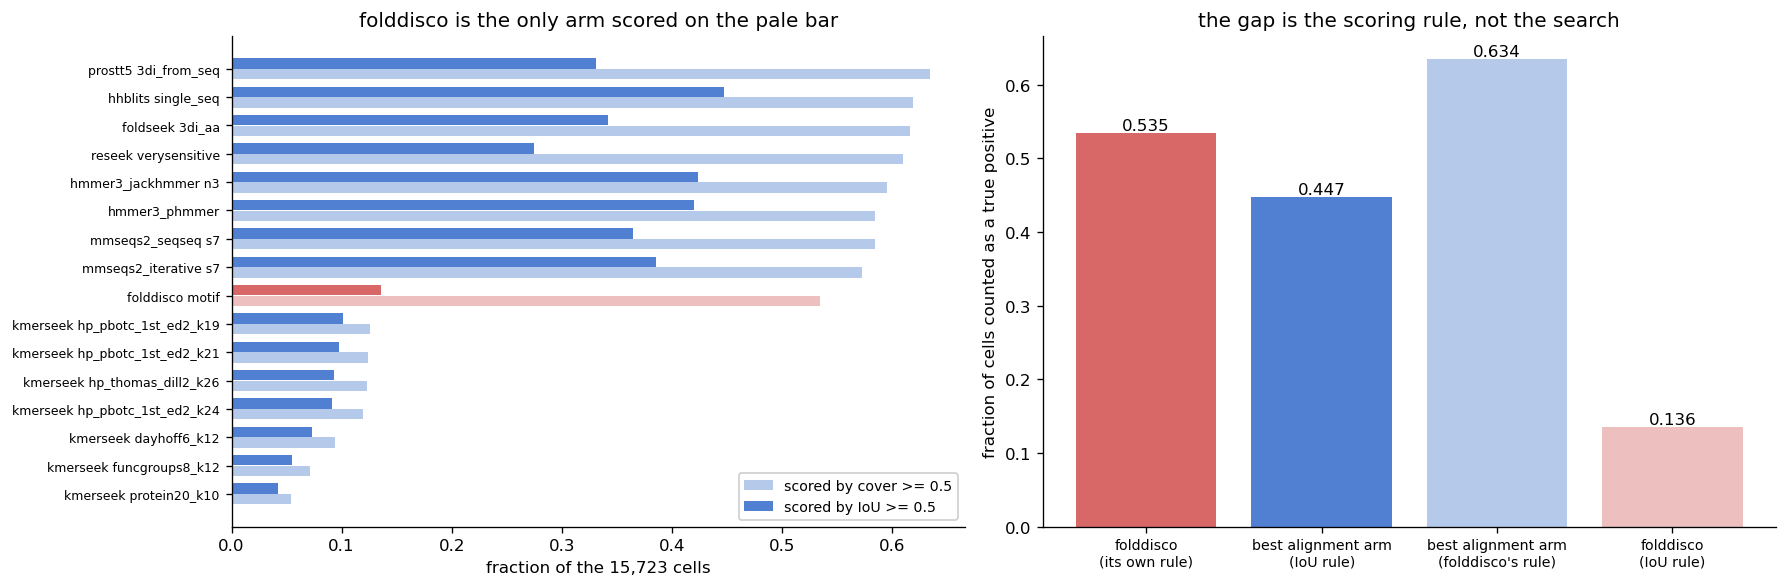

In [8]:
sem = (
    metrics.group_by("tool")
    .agg(
        interval_semantics=pl.col("interval_semantics").unique(),
        point_semantics=pl.col("point_semantics").unique(),
    )
    .sort("tool")
)
print("interval semantics per tool, pfam truth:")
with pl.Config(tbl_rows=15, tbl_width_chars=150):
    print(sem)

fd_cmp = (
    GRID.group_by("arm")
    .agg(
        iou50=(pl.col("best_iou") >= 0.5).mean().round(4),
        cover50=(pl.col("best_cover") >= 0.5).mean().round(4),
        pipeline_tp=pl.col("any_tp").mean().round(4),
        iou50_unreachable=(pl.col("best_iou") >= 0.5)
        .filter(pl.col("present") & ~pl.col("reachable"))
        .mean()
        .round(4),
        cover50_unreachable=(pl.col("best_cover") >= 0.5)
        .filter(pl.col("present") & ~pl.col("reachable"))
        .mean()
        .round(4),
    )
    .sort("cover50", descending=True)
)
print()
print(
    "Scored two ways. `pipeline_tp` is the run's own flag, which is IoU for every arm"
)
print("except folddisco, where it is cover:")
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=45):
    print(fd_cmp)

fd = fd_cmp.filter(pl.col("arm") == "folddisco.motif")
aln_best_tp = fd_cmp.filter(pl.col("arm") != "folddisco.motif")["pipeline_tp"].max()
aln_best_cov = fd_cmp.filter(pl.col("arm") != "folddisco.motif")["cover50"].max()
print()
print(f"folddisco under its own rule:                       {fd['pipeline_tp'][0]:.4f}")
print(f"best alignment arm under the IoU rule:              {aln_best_tp:.4f}")
print(f"best alignment arm scored the way folddisco is:     {aln_best_cov:.4f}")
print(f"folddisco under the IoU rule the others face:       {fd['iou50'][0]:.4f}")
print()
mouse_fmax = (
    tool_fmax.filter(pl.col("species") == "mouse")
    .select("tool", "interval_semantics", pl.col("fmax").round(3))
    .sort("fmax", descending=True)
)
print("Mouse Fmax, best variant per tool:")
with pl.Config(tbl_rows=15, tbl_width_chars=140):
    print(mouse_fmax)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.0))
ax = axes[0]
f = fd_cmp.sort("cover50")
yy = np.arange(f.height)
cols = ["#D65F5F" if a == "folddisco.motif" else "#4878CF" for a in f["arm"]]
ax.barh(
    yy - 0.19, f["cover50"], 0.36, color=cols, alpha=0.4, label="scored by cover >= 0.5"
)
ax.barh(
    yy + 0.19, f["iou50"], 0.36, color=cols, alpha=0.95, label="scored by IoU >= 0.5"
)
ax.set_yticks(yy)
ax.set_yticklabels(
    [
        a.replace("_lcTrue", "").replace(".default", "").replace(".", " ")
        for a in f["arm"]
    ],
    fontsize=7.5,
)
ax.set_xlabel("fraction of the 15,723 cells")
ax.set_title("folddisco is the only arm scored on the pale bar")
ax.legend(fontsize=8.5, loc="lower right", framealpha=0.95)

ax = axes[1]
labels = [
    "folddisco\n(its own rule)",
    "best alignment arm\n(IoU rule)",
    "best alignment arm\n(folddisco's rule)",
    "folddisco\n(IoU rule)",
]
vals = [fd["pipeline_tp"][0], aln_best_tp, aln_best_cov, fd["iou50"][0]]
cols2 = ["#D65F5F", "#4878CF", "#4878CF", "#D65F5F"]
alphas = [0.95, 0.95, 0.4, 0.4]
for i, (v, c_, a_) in enumerate(zip(vals, cols2, alphas)):
    ax.bar([i], [v], color=c_, alpha=a_)
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=10)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel("fraction of cells counted as a true positive")
ax.set_title("the gap is the scoring rule, not the search")
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "226_folddisco_gap.png", dpi=200)

### 5.3 kmerseek: high IoU on true positives, low recall

The claim to test is that kmerseek's true positives sit high on IoU because they are
selected from the easy end of the census — short domains in mostly-domain proteins, families
with many partner-free targets. If that were the reason, kmerseek's true positives would be
enriched for high length fraction relative to other arms.

mean length fraction of the reachable pool, for reference: 0.38

True-positive profile per arm. If kmerseek's TPs were an easy-end selection,
`mean_lf_of_tp` and `frac_tp_cond1` would be highest for kmerseek:
shape: (15, 9)
┌──────────────────────────────────────┬──────┬───────────────┬───────────────┬───┬───────────────────┬─────────┬───────────┬─────────────────────────┐
│ arm                                  ┆ n_tp ┆ median_iou_tp ┆ mean_lf_of_tp ┆ … ┆ median_solo_of_tp ┆ covered ┆ delimited ┆ delimited_given_covered │
│ ---                                  ┆ ---  ┆ ---           ┆ ---           ┆   ┆ ---               ┆ ---     ┆ ---       ┆ ---                     │
│ str                                  ┆ i64  ┆ f64           ┆ f64           ┆   ┆ f64               ┆ f64     ┆ f64       ┆ f64                     │
╞══════════════════════════════════════╪══════╪═══════════════╪═══════════════╪═══╪═══════════════════╪═════════╪═══════════╪═════════════════════════╡
│ kmerseek.hp_pb

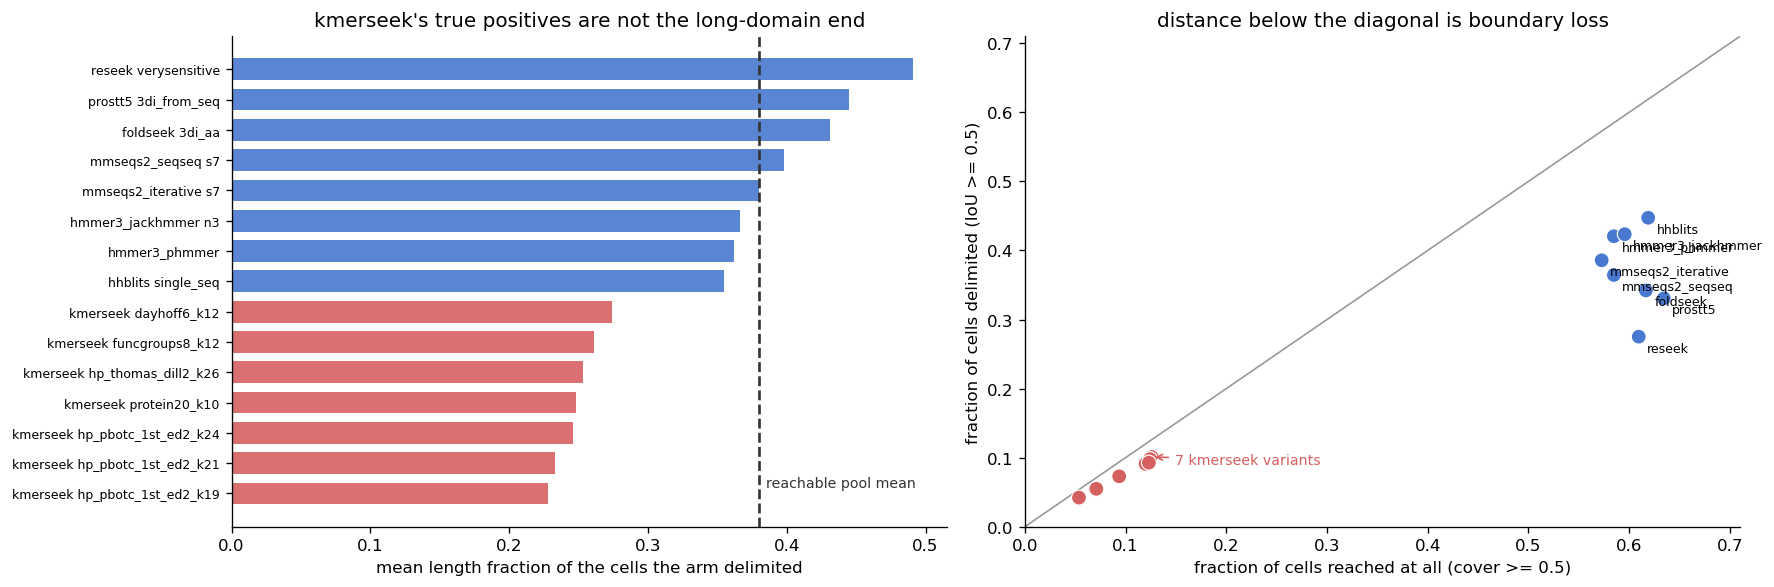

In [9]:
KM = "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue"
tp_profile = []
for arm in sorted(ALN["arm"].unique().to_list()):
    s = ALN.filter(pl.col("arm") == arm)
    tp = s.filter(pl.col("best_iou") >= 0.5)
    cov = s.filter(pl.col("best_cover") >= 0.5)
    tp_profile.append(
        {
            "arm": arm,
            "n_tp": tp.height,
            "median_iou_tp": (
                None if tp.height == 0 else round(tp["best_iou"].median(), 3)
            ),
            "mean_lf_of_tp": None if tp.height == 0 else round(tp["max_lf"].mean(), 3),
            "frac_tp_cond1": (
                None
                if tp.height == 0
                else round(float((tp["max_lf"] >= 0.5).mean()), 3)
            ),
            "median_solo_of_tp": (
                None if tp.height == 0 else float(tp["n_solo_targets"].median())
            ),
            "covered": round(cov.height / s.height, 4),
            "delimited": round(tp.height / s.height, 4),
            "delimited_given_covered": (
                None if cov.height == 0 else round(tp.height / cov.height, 3)
            ),
        }
    )
prof = pl.DataFrame(tp_profile).sort("delimited_given_covered", descending=True)
pool_lf = round(float(ALN.filter(pl.col("reachable"))["max_lf"].mean()), 3)
print(f"mean length fraction of the reachable pool, for reference: {pool_lf}")
print()
print("True-positive profile per arm. If kmerseek's TPs were an easy-end selection,")
print("`mean_lf_of_tp` and `frac_tp_cond1` would be highest for kmerseek:")
with pl.Config(tbl_rows=20, tbl_width_chars=210, fmt_str_lengths=45):
    print(prof)

km_med = metrics.filter(pl.col("tool") == "kmerseek")["median_iou_tp"].median()
ph_med = metrics.filter(pl.col("tool") == "hmmer3_phmmer")["median_iou_tp"].median()
mm_med = metrics.filter(pl.col("tool") == "mmseqs2_seqseq")["median_iou_tp"].median()
print()
print("Pipeline `median_iou_tp` (median over TP calls, not per instance), pfam truth:")
print(f"  kmerseek {km_med:.3f}   phmmer {ph_med:.3f}   MMseqs2 {mm_med:.3f}")
print("kmerseek is not the highest on that column in the pfam truth set.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.0))
ax = axes[0]
p = prof.sort("mean_lf_of_tp")
yy = np.arange(p.height)
cols = ["#D65F5F" if a.startswith("kmerseek") else "#4878CF" for a in p["arm"]]
ax.barh(yy, p["mean_lf_of_tp"], 0.72, color=cols, alpha=0.9)
ax.axvline(pool_lf, color="#333333", lw=1.6, ls="--")
ax.text(pool_lf + 0.005, 0.2, "reachable pool mean", fontsize=8.5, color="#333333")
ax.set_yticks(yy)
ax.set_yticklabels(
    [
        a.replace("_lcTrue", "").replace(".default", "").replace(".", " ")
        for a in p["arm"]
    ],
    fontsize=7.5,
)
ax.set_xlabel("mean length fraction of the cells the arm delimited")
ax.set_title("kmerseek's true positives are not the long-domain end")

ax = axes[1]
ax.scatter(
    prof["covered"],
    prof["delimited"],
    s=80,
    color=["#D65F5F" if a.startswith("kmerseek") else "#4878CF" for a in prof["arm"]],
    edgecolor="white",
    linewidth=0.7,
    zorder=3,
)
lim = float(max(prof["covered"].max(), prof["delimited"].max())) * 1.12
ax.plot([0, lim], [0, lim], color="#999999", lw=1.0)
for row in prof.iter_rows(named=True):
    if row["arm"].startswith("kmerseek"):
        continue
    ax.annotate(
        row["arm"].split(".")[0],
        (row["covered"], row["delimited"]),
        fontsize=7.5,
        xytext=(5, -9),
        textcoords="offset points",
    )
km = prof.filter(pl.col("arm").str.starts_with("kmerseek"))
ax.annotate(
    f"{km.height} kmerseek variants",
    (km["covered"].max(), km["delimited"].max()),
    fontsize=8.5,
    color="#D65F5F",
    xytext=(14, -4),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1.0, color="#D65F5F"),
)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("fraction of cells reached at all (cover >= 0.5)")
ax.set_ylabel("fraction of cells delimited (IoU >= 0.5)")
ax.set_title("distance below the diagonal is boundary loss")
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "226_kmerseek_iou.png", dpi=200)

## Summary

Of the 21,222 (domain instance, target species) pairs in the answer key, 31.9% have the Pfam
family absent from the target proteome and 21.6% have it present but failing both of the
conditions that make a true positive geometrically possible. 53.5% is therefore not predicted
reachable and 46.5% is. Per species the reachable fraction runs from 0.649 in mouse down to
0.066 in E. coli, with chicken 0.475 and zebrafish 0.594. The expectation about domain sizes
holds: the median truth domain is 90 aa in a 612-aa protein, median length fraction 0.133,
and only 400 of 2,358 instances (17.0%) are at least half their protein.

On the 51 MHC domains the classification splits outcomes cleanly: the ten headline arms
delimit 75.3% of predicted-reachable (gene, family, species) cells and 6.5% of the rest,
and 98.3% of reachable cells are delimited by at least one arm against 21.1% of the rest.

The absent class is a hard floor and the structural class is not. No cell whose family is
missing from the target was delimited by any of the fifteen alignment arms, in any species,
ever. The length-fraction class is delimited by at least one arm 99.6% of the time and the
single-domain-target class 95.0%, so both conditions work as sufficient rules. But the class
that fails both is still delimited by at least one arm 60.4% of the time, so neither
condition is necessary: a local alignment against a multi-domain target can stop at the
domain and inherit a tight boundary anyway. For a single arm the effect is a large handicap
rather than an impossibility — phmmer delimits 80.4% of predicted-reachable cells against
34.0% of the cells that are present but predicted unreachable, and hhblits 88.3% against
31.4%. 99.9% of the structurally unreachable cells are covered by some arm, so what is lost
there is the boundary, not the detection.

The two covariates explain a third to a half of the between-family spread. On per-(family,
species) recall, length fraction alone gives R² 0.13-0.44 across the eight alignment arms,
adding log single-domain-target count reaches 0.25-0.54, and adding the largest fraction of a
target protein that one instance of the family occupies reaches 0.27-0.59. That last
covariate is condition 2 stated continuously and is the stronger of the two target-side
terms. The structure-based arms (reseek 0.54, prostt5 0.51, foldseek 0.48) are the most
predictable from truth-set geometry alone; hmmer-family arms the least (0.25-0.29). kmerseek
is the exception at R² 0.02, because its recall is limited by sensitivity rather than by
boundary geometry.

Every reported Fmax sits on a denominator roughly half of which cannot be answered. An arm
that delimited every predicted-reachable cell and nothing else would score recall 0.422 on
the full key; the best observed single arm is 0.447, slightly above, because condition 2 is
not necessary. Mean Fmax across the nine species is 0.117-0.292 depending on tool, which is
what a recall ceiling near 0.42 looks like once precision is folded in. Against the reachable
block alone the same searches score 0.64-0.86.

folddisco is the only arm with `interval_semantics = "motif"` and `point_semantics =
"cover"`, so its true positives are decided by cover rather than IoU. Under its own rule it
counts 53.5% of cells as true positives; under the IoU rule the other arms face, 13.5%. Its
median IoU on its own true positives is 0.16, and it clears IoU 0.5 on 0.4% of the
structurally unreachable cells against 79% covered. Scoring the best alignment arm the way
folddisco is scored gives 63.5%, above folddisco, so the ranking inverts once the rule is
matched. Two corrections to the framing: on mouse folddisco does lead at Fmax 0.454 against
0.25-0.33 for the alignment tools and 0.437 for the best kmerseek arm, but averaged over the
nine species its Fmax is 0.134, below every sequence tool, so the 0.44-0.51 band is a
mouse-only number.

kmerseek's high conditional IoU is not a selection effect of the census. Its true positives
have mean length fraction 0.228, below the reachable-pool mean of 0.380 and below phmmer's
0.362, foldseek's 0.431 and reseek's 0.491, so they come from the short-domain end rather
than the easy long-domain end, and their median single-domain-target count is 2 against 3-5
for the alignment arms. The reason is call length: kmerseek delimits 80.1% of the cells it
reaches at all, the highest ratio of any arm, against 72.3% for hhblits, 71.9% for phmmer,
45.1% for reseek and 25.3% for folddisco. Its calls are short enough that reaching a domain
and delimiting it are nearly the same event, so its low recall is a sensitivity limit rather
than a boundary limit. One correction: in the pfam truth set kmerseek's pipeline
`median_iou_tp` is 0.618, below phmmer's 0.725 and MMseqs2's 0.757, so it is not the highest
on that column; the statistic that is genuinely highest for kmerseek is delimited-given-
covered.

For the report, the absolute Fmax numbers are not comparable to a published domain-boundary
benchmark; they are recall against a key roughly half of which cannot be answered.
Cross-tool comparisons within the run stay valid as long as the interval semantics match,
which they do not for folddisco. The reachability floor should be reported alongside every
recall figure, computed as family presence in the target — the pipeline's own
`n_reachable_instances` matches that count exactly in the pfam slice for all nine species —
and the structural block reported as a second, softer handicap rather than folded into the
same denominator.